In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Load dataset (adjust path relative to your notebooks folder)
df = pd.read_csv('../data/alt_fuel_stations (Jul 29 2026).csv', low_memory=False)

# Clean numeric port counts
df['EV Level2 EVSE Num'] = df['EV Level2 EVSE Num'].fillna(0)
df['EV DC Fast Count'] = df['EV DC Fast Count'].fillna(0)
df['Total Ports'] = df['EV Level2 EVSE Num'] + df['EV DC Fast Count']

# Parse installation dates
df['Open Date Clean'] = pd.to_datetime(df['Open Date'], errors='coerce')
df['Year'] = df['Open Date Clean'].dt.year

# Clean categorical variables
df['EV Network Clean'] = df['EV Network'].fillna('Unknown / Non-Networked')
df['Access Code'] = df['Access Code'].str.title().fillna('Public')
df['Facility Type Clean'] = df['Facility Type'].fillna('Uncategorized')

print(f"Dataset loaded successfully with {len(df):,} records!")

Dataset loaded successfully with 105,705 records!


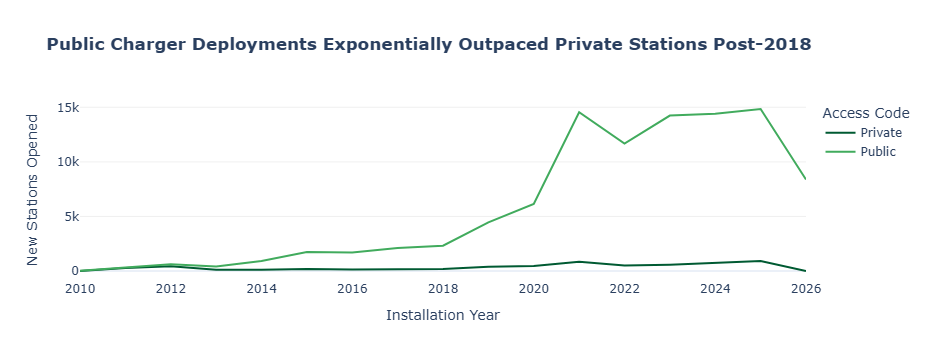

In [3]:
## Question 1: How have public vs. private station deployments evolved over time?
#**Analytical Focus:** Spatial/Temporal comparative growth across public and private accessibility models.
df_q1 = df[(df['Year'] >= 2010) & (df['Year'] <= 2026)].groupby(['Year', 'Access Code'])['ID'].count().reset_index()

fig1 = px.line(
    df_q1, x='Year', y='ID', color='Access Code',
    title="<b>Public Charger Deployments Exponentially Outpaced Private Stations Post-2018</b>",
    labels={'ID': 'New Stations Opened', 'Year': 'Installation Year'},
    color_discrete_sequence=['#005a32', '#41ab5d'],
    template='plotly_white'
)
fig1.update_xaxes(showgrid=False)
fig1.update_yaxes(showgrid=True, gridcolor='#f0f0f0')
fig1.show()

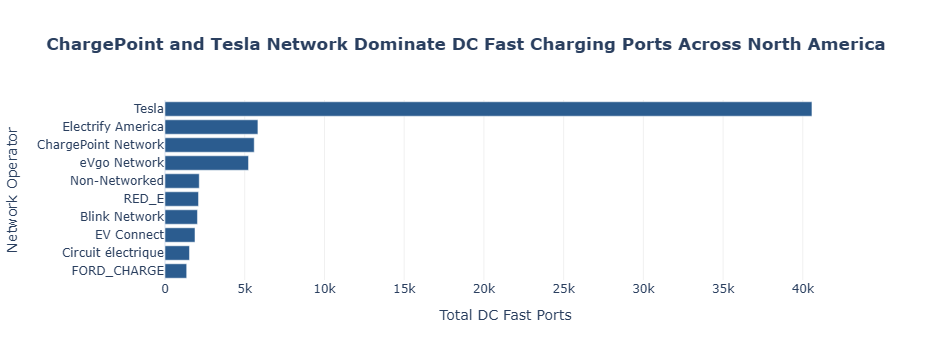

In [4]:
## Question 2: Which network operators dominate DC Fast Charging ports?
#**Analytical Focus:** Categorical network operator breakdown crossed with DC Fast Port capacity.
df_q2 = df.groupby('EV Network Clean')['EV DC Fast Count'].sum().reset_index().sort_values(by='EV DC Fast Count', ascending=False).head(10)

fig2 = px.bar(
    df_q2, x='EV DC Fast Count', y='EV Network Clean', orientation='h',
    title="<b>ChargePoint and Tesla Network Dominate DC Fast Charging Ports Across North America</b>",
    labels={'EV DC Fast Count': 'Total DC Fast Ports', 'EV Network Clean': 'Network Operator'},
    color_discrete_sequence=['#2b5c8f'],
    template='plotly_white'
)
fig2.update_layout(yaxis={'categoryorder':'total ascending'})
fig2.update_xaxes(showgrid=True, gridcolor='#f0f0f0')
fig2.show()

In [5]:
## Question 3: Where are spatial infrastructure clusters and charging deserts located?
#**Analytical Focus:** Spatial coordinates (Latitude/Longitude) weighted by port size and access type.
df_q3 = df.dropna(subset=['Latitude', 'Longitude']).sample(3000, random_state=42)

fig3 = px.scatter_mapbox(
    df_q3, lat="Latitude", lon="Longitude", color="Access Code", size="Total Ports",
    color_discrete_sequence=['#2171b5', '#6baed6'],
    hover_name="Station Name", zoom=3, height=500,
    title="<b>Coastal Metropolitan Corridors Exhibit Highest Infrastructure Cluster Density</b>"
)
fig3.update_layout(mapbox_style="carto-positron")
fig3.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_10216\1780392247.py:5: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



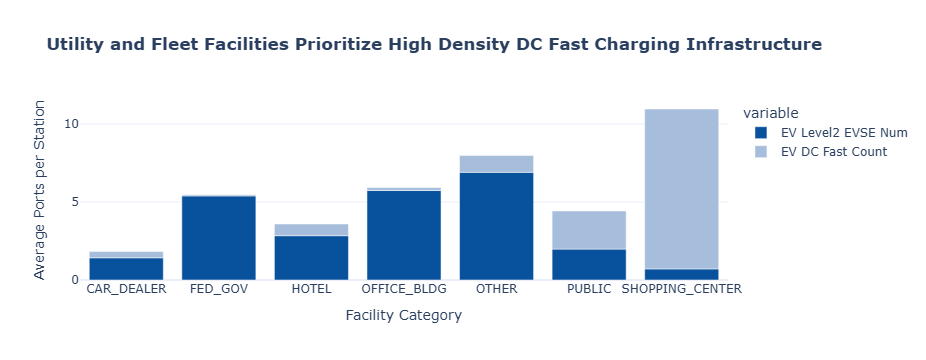

In [6]:
## Question 4: How do facility types differ in their charging port technology strategy?
#**Analytical Focus:** Facility categories crossed with Level 2 vs. DC Fast port counts.

top_facilities = df['Facility Type Clean'].value_counts().head(8).index
df_q4 = df[df['Facility Type Clean'].isin(top_facilities) & (df['Facility Type Clean'] != 'Uncategorized')]
df_q4_grouped = df_q4.groupby('Facility Type Clean')[['EV Level2 EVSE Num', 'EV DC Fast Count']].mean().reset_index()

fig4 = px.bar(
    df_q4_grouped, x='Facility Type Clean', y=['EV Level2 EVSE Num', 'EV DC Fast Count'],
    title="<b>Utility and Fleet Facilities Prioritize High Density DC Fast Charging Infrastructure</b>",
    labels={'value': 'Average Ports per Station', 'Facility Type Clean': 'Facility Category'},
    color_discrete_sequence=['#08519c', '#a6bddb'],
    template='plotly_white'
)
fig4.update_xaxes(showgrid=False)
fig4.show()

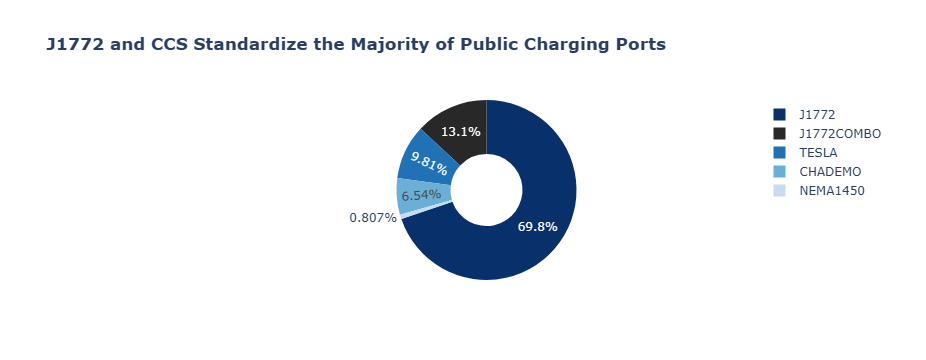

In [7]:
## Question 5: What is the market share distribution of EV connector standards?
#**Analytical Focus:** Categorical connector type frequencies (J1772, CCS, CHAdeMO, NACS).

df_connectors = df['EV Connector Types'].dropna().str.split(' ').explode().value_counts().reset_index()
df_connectors.columns = ['Connector Standard', 'Count']

fig5 = px.pie(
    df_connectors.head(5), values='Count', names='Connector Standard',
    title="<b>J1772 and CCS Standardize the Majority of Public Charging Ports</b>",
    color_discrete_sequence=['#08306b', '#282828', '#2171b5', '#6baed6', '#c6dbef'],
    hole=0.4
)
fig5.show()

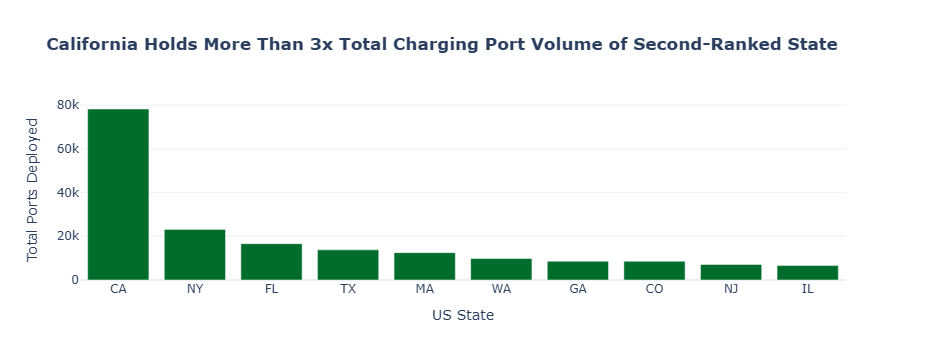

In [8]:
## Question 6: Which top US states lead in total EV port volume?
#**Analytical Focus:** Spatial aggregate state-level port distribution.

df_q6 = df[df['Country'] == 'US'].groupby('State')['Total Ports'].sum().reset_index().sort_values(by='Total Ports', ascending=False).head(10)

fig6 = px.bar(
    df_q6, x='State', y='Total Ports',
    title="<b>California Holds More Than 3x Total Charging Port Volume of Second-Ranked State</b>",
    labels={'Total Ports': 'Total Ports Deployed', 'State': 'US State'},
    color_discrete_sequence=['#006d2c'],
    template='plotly_white'
)
fig6.update_xaxes(showgrid=False)
fig6.show()

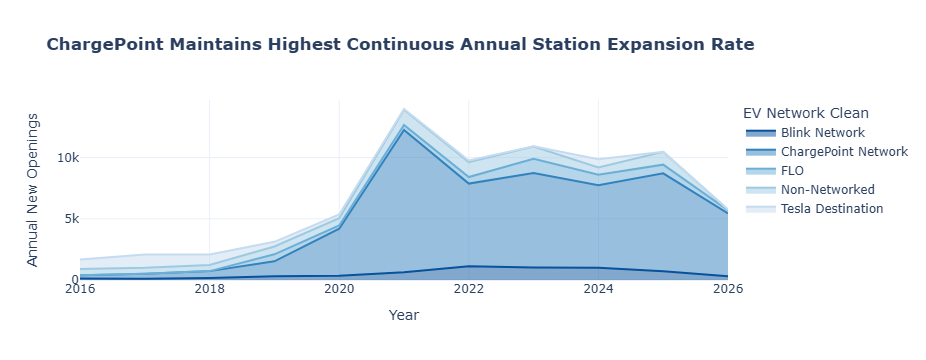

In [9]:
## Question 7: How has annual expansion speed varied among top operators?
#**Analytical Focus:** Temporal trajectory of station deployments for top 5 network operators.

top_5_nets = df['EV Network Clean'].value_counts().head(5).index
df_q7 = df[(df['EV Network Clean'].isin(top_5_nets)) & (df['Year'] >= 2016) & (df['Year'] <= 2026)]
df_q7_grouped = df_q7.groupby(['Year', 'EV Network Clean'])['ID'].count().reset_index()

fig7 = px.area(
    df_q7_grouped, x='Year', y='ID', color='EV Network Clean',
    title="<b>ChargePoint Maintains Highest Continuous Annual Station Expansion Rate</b>",
    labels={'ID': 'Annual New Openings', 'Year': 'Year'},
    color_discrete_sequence=['#08519c', '#3182bd', '#6baed6', '#9ecae1', '#c6dbef'],
    template='plotly_white'
)
fig7.show()

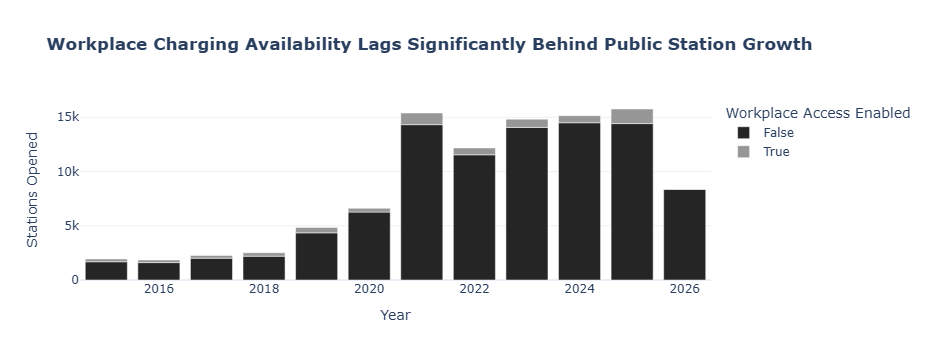

In [10]:
## Question 8: How does workplace charging access compare to public commercial access?
#**Analytical Focus:** Categorical workplace charging flag tracked across installation years.

df_q8 = df[(df['Year'] >= 2015) & (df['Year'] <= 2026)].groupby(['Year', 'EV Workplace Charging'])['ID'].count().reset_index()

fig8 = px.bar(
    df_q8, x='Year', y='ID', color='EV Workplace Charging',
    title="<b>Workplace Charging Availability Lags Significantly Behind Public Station Growth</b>",
    labels={'ID': 'Stations Opened', 'EV Workplace Charging': 'Workplace Access Enabled'},
    color_discrete_sequence=['#252525', '#969696'],
    template='plotly_white'
)
fig8.show()

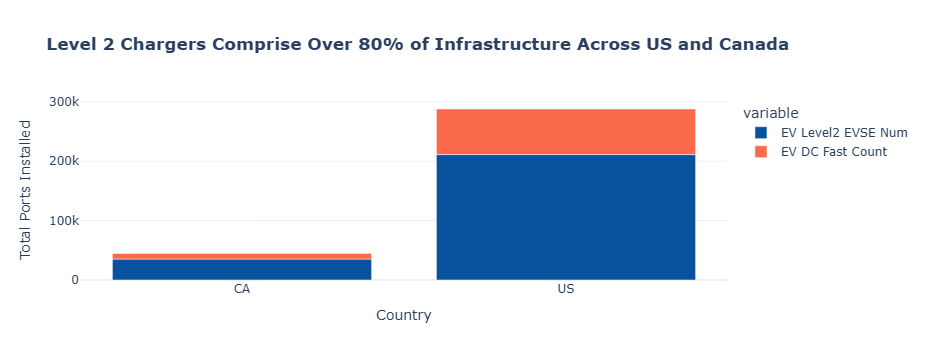

In [11]:
## Question 9: How do port type ratios compare between US and Canadian deployments?
#**Analytical Focus:** Cross-country comparative analysis on Level 2 vs. DC Fast infrastructure focus.

df_q9 = df.groupby('Country')[['EV Level2 EVSE Num', 'EV DC Fast Count']].sum().reset_index()

fig9 = px.bar(
    df_q9, x='Country', y=['EV Level2 EVSE Num', 'EV DC Fast Count'],
    title="<b>Level 2 Chargers Comprise Over 80% of Infrastructure Across US and Canada</b>",
    labels={'value': 'Total Ports Installed', 'Country': 'Country'},
    color_discrete_sequence=['#08519c', '#fb6a4a'],
    template='plotly_white'
)
fig9.show()

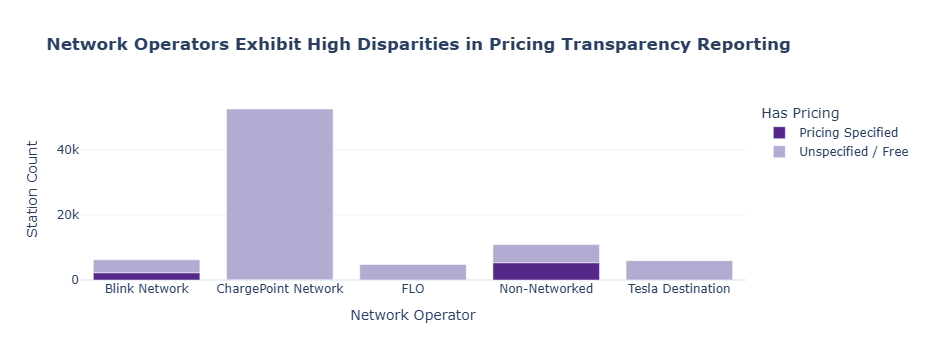

In [12]:
## Question 10: How transparently do networks report public pricing structures?
#**Analytical Focus:** Operator network transparency based on explicit pricing attributes.

df['Has Pricing'] = df['EV Pricing'].notna().map({True: 'Pricing Specified', False: 'Unspecified / Free'})
df_q10 = df[df['EV Network Clean'].isin(top_5_nets)].groupby(['EV Network Clean', 'Has Pricing'])['ID'].count().reset_index()

fig10 = px.bar(
    df_q10, x='EV Network Clean', y='ID', color='Has Pricing',
    title="<b>Network Operators Exhibit High Disparities in Pricing Transparency Reporting</b>",
    labels={'ID': 'Station Count', 'EV Network Clean': 'Network Operator'},
    color_discrete_sequence=['#542788', '#b2abd2'],
    template='plotly_white'
)
fig10.show()